# AgriSmart - Notebook de travail

## Detection de maladies des cultures a partir d'images de feuilles

Ce notebook presente un prototype simple et lisible.

L'idee est de comparer deux approches :
- un CNN simple cree depuis zero
- un modele MobileNetV2 en transfer learning

Le document est volontairement decoupe en petites etapes pour faciliter la lecture.


## Plan du notebook

1. Importer les bibliotheques
2. Definir les parametres du projet
3. Charger le dataset
4. Explorer rapidement les images
5. Creer les jeux d'entrainement, validation et test
6. Entrainer un CNN simple
7. Entrainer MobileNetV2
8. Comparer les resultats


## 1. Importation des bibliotheques

Cette cellule charge les outils utilises pour la visualisation, la preparation des donnees et l'entrainement des modeles.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator


## 2. Parametres du projet

On centralise ici les chemins et les principaux reglages.
Cela permet de modifier le projet plus facilement sans toucher a tout le notebook.


In [2]:
# Le notebook peut etre lance depuis le dossier notebooks ou depuis la racine du projet.
PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_DIR = PROJECT_DIR / "data" / "raw"
MODELS_DIR = PROJECT_DIR / "models"
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

CNN_EPOCHS = 10
HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 5

sns.set_theme(style="whitegrid")
tf.keras.utils.set_random_seed(SEED)

print("Dossier projet :", PROJECT_DIR)
print("Dossier donnees :", DATA_DIR)


Dossier projet : C:\projet phase 3
Dossier donnees : C:\projet phase 3\data\raw


## 3. Structure attendue du dataset

Les images doivent etre classees par dossier.

Exemple :

```text
data/
  raw/
    healthy/
    fungal/
    viral/
```

Chaque sous-dossier represente une classe.


## 4. Chargement des chemins d'images

Ici, on construit un petit tableau avec deux colonnes :
- le chemin de l'image
- le nom de la classe


In [3]:
valid_extensions = {".jpg", ".jpeg", ".png"}
records = []

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Le dossier {DATA_DIR} est introuvable.")

for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    for image_path in class_dir.rglob("*"):
        if image_path.suffix.lower() in valid_extensions:
            records.append(
                {
                    "filepath": str(image_path),
                    "label": class_dir.name,
                }
            )

images_df = pd.DataFrame(records)
images_df.head()


,filepath,label
0,C:\projet phase 3\data\raw\common_rust\RS_Rust...,common_rust
1,C:\projet phase 3\data\raw\common_rust\RS_Rust...,common_rust
2,C:\projet phase 3\data\raw\common_rust\RS_Rust...,common_rust
3,C:\projet phase 3\data\raw\common_rust\RS_Rust...,common_rust
4,C:\projet phase 3\data\raw\common_rust\RS_Rust...,common_rust


In [4]:
# Cette verification evite de continuer si les images ne sont pas encore en place.
if images_df.empty:
    raise ValueError("Aucune image detectee dans data/raw. Ajoute d'abord les images par classe.")

print("Nombre total d'images :", len(images_df))
print("Classes detectees :", sorted(images_df["label"].unique()))


Nombre total d'images : 3339
Classes detectees : ['common_rust', 'healthy', 'northern_leaf_blight']


## 4bis. Audit rapide des fichiers

Cette verification reprend l'idee du nettoyage technique du notebook d'Eli.
Elle permet de s'assurer que les images du sous-ensemble utilise peuvent etre ouvertes correctement avant l'entrainement.

In [5]:
from PIL import Image

corrupted_files = []

for file_path in images_df["filepath"]:
    try:
        with Image.open(file_path) as img:
            img.verify()
    except Exception:
        corrupted_files.append(file_path)

print("Fichiers corrompus detectes :", len(corrupted_files))
if corrupted_files:
    display(pd.DataFrame({"filepath": corrupted_files}).head())
else:
    print("Aucun fichier corrompu detecte dans le sous-ensemble utilise.")

Fichiers corrompus detectes : 0
Aucun fichier corrompu detecte dans le sous-ensemble utilise.


## 5. Exploration rapide du dataset

Avant d'entrainer un modele, il faut verifier si les classes sont bien representees.


In [6]:
class_counts = images_df["label"].value_counts().sort_index()
class_counts


label
common_rust             1192
healthy                 1162
northern_leaf_blight     985
Name: count, dtype: int64

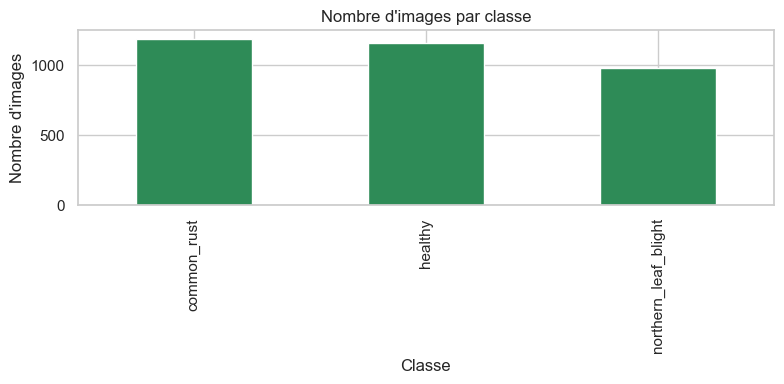

In [7]:
plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar", color="seagreen")
plt.title("Nombre d'images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()


## 6. Affichage de quelques images

Cette etape permet de verifier visuellement que les images correspondent bien au probleme pose.


In [8]:
def show_sample_images(dataframe, n=6):
    sample_df = dataframe.sample(min(n, len(dataframe)), random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(12, 6))

    for i, row in sample_df.iterrows():
        image = plt.imread(row["filepath"])
        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(row["label"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


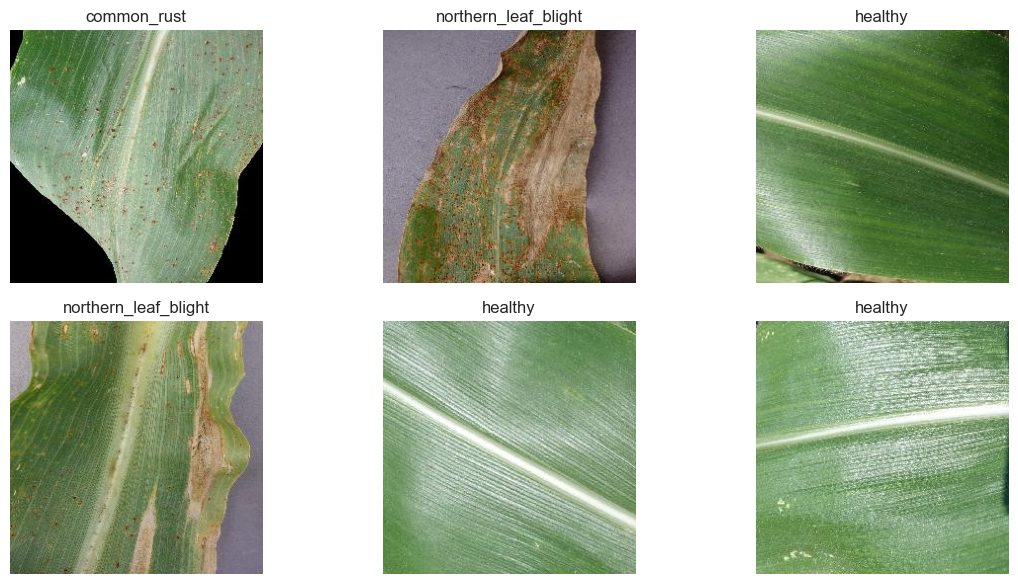

In [9]:
show_sample_images(images_df)


## 7. Separation des donnees

On separe les images en trois groupes :
- entrainement
- validation
- test

Le jeu de test ne doit pas etre utilise pendant l'entrainement.


In [10]:
train_df, temp_df = train_test_split(
    images_df,
    test_size=0.30,
    stratify=images_df["label"],
    random_state=SEED,
)


In [11]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))


Train : 2337
Validation : 501
Test : 501


## 8. Generateurs d'images

Les generateurs lisent les images par petits lots.

Pour l'entrainement, on applique aussi de la data augmentation afin de simuler des conditions reelles :
- rotation legere
- zoom
- variation de luminosite
- deplacements simples


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)


In [13]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)


Found 2337 validated image filenames belonging to 3 classes.


In [14]:
val_gen = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    class_mode="sparse",
    batch_size=BATCH_SIZE,
    shuffle=False,
)


Found 501 validated image filenames belonging to 3 classes.


Found 501 validated image filenames belonging to 3 classes.


In [15]:
class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)

print("Classes :", class_names)
print("Nombre de classes :", num_classes)


Classes : ['common_rust', 'healthy', 'northern_leaf_blight']
Nombre de classes : 3


## 9. Verification d'un lot d'images

Cette visualisation montre un exemple de lot charge par le generateur.


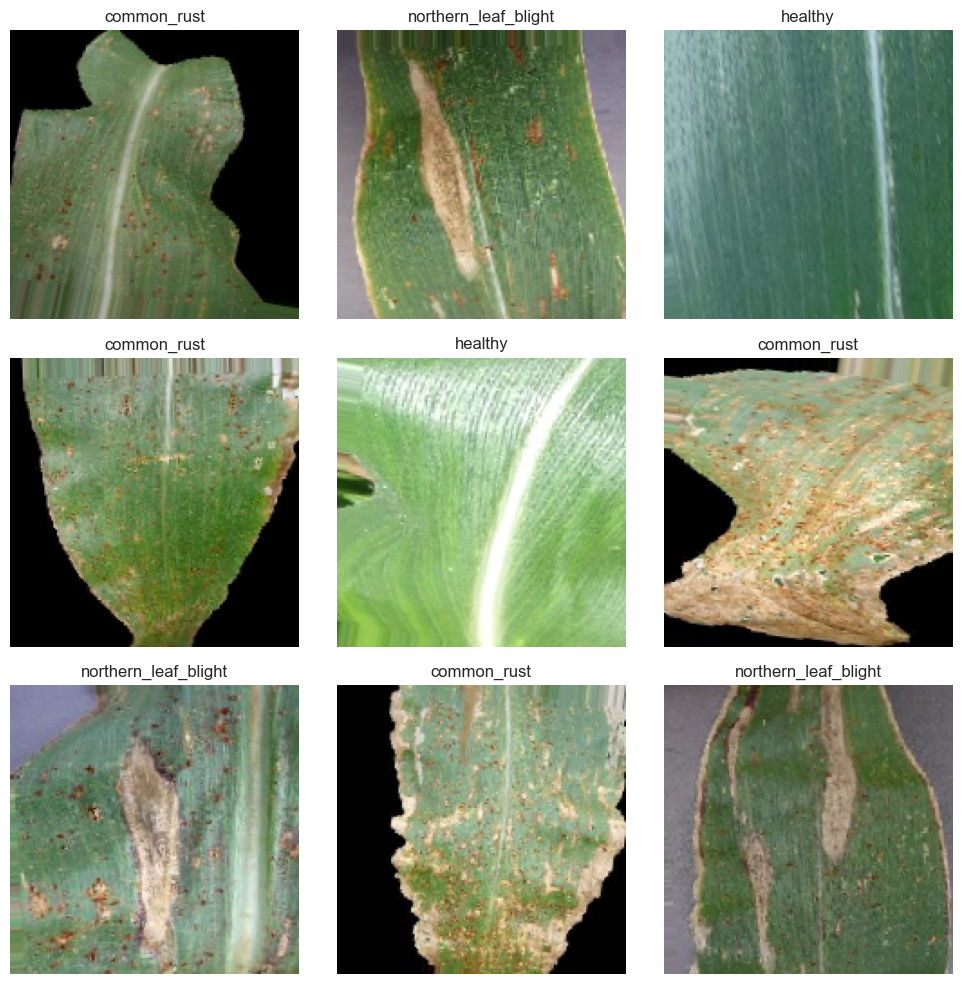

In [16]:
images_batch, labels_batch = next(train_gen)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    plt.title(class_names[int(labels_batch[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# On remet le generateur au debut avant l'entrainement.
train_gen.reset()


## 10. Premier modele : CNN simple

Ce modele sert de point de depart.
Il est plus simple qu'un modele pre-entraine et permet d'avoir une premiere base de comparaison.


In [17]:
cnn_model = models.Sequential(
    [
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,363 (25.36 MB)

 Trainable params: 6,647,363 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [19]:
cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / "cnn_simple.keras"),
        save_best_only=True,
        monitor="val_loss",
    ),
]


In [20]:
train_gen.reset()
val_gen.reset()

history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CNN_EPOCHS,
    callbacks=cnn_callbacks,
)


Epoch 1/10


 1/74 ━━━━━━━━━━━━━━━━━━━━ 2:03 2s/step - accuracy: 0.2500 - loss: 1.1085

 2/74 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.2891 - loss: 1.0837

 3/74 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.2969 - loss: 1.0920

 4/74 ━━━━━━━━━━━━━━━━━━━━ 18s 258ms/step - accuracy: 0.3320 - loss: 1.0819

...

71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9938 - loss: 0.0209

72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9938 - loss: 0.0209

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9938 - loss: 0.0209

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9937 - loss: 0.0209

74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 338ms/step - accuracy: 0.9932 - loss: 0.0217 - val_accuracy: 0.9940 - val_loss: 0.0448


## 11. Lecture des courbes d'apprentissage

Les courbes montrent si le modele apprend correctement et si un surapprentissage apparait.


In [21]:
def plot_history(history, title):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    history_df[["loss", "val_loss"]].plot(ax=axes[0], title=f"{title} - Loss")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title=f"{title} - Accuracy")

    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()


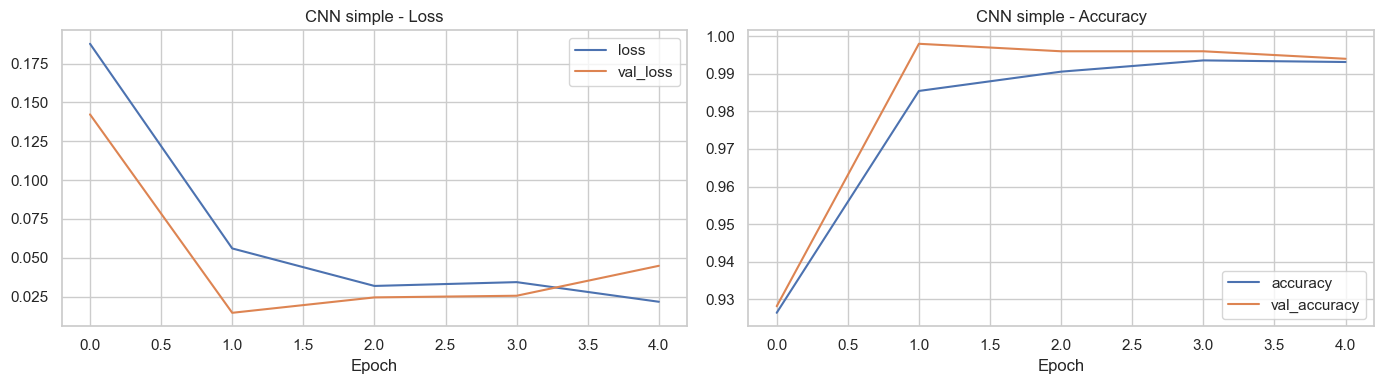

In [22]:
plot_history(history_cnn, "CNN simple")


## 12. Deuxieme modele : MobileNetV2

Cette approche reutilise un modele deja entraine sur un grand volume d'images.
L'objectif est de voir si cette base pre-entrainee apporte de meilleures performances.


In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

# Au debut, on gele les couches du modele pre-entraine.
base_model.trainable = False


In [24]:
transfer_model = models.Sequential(
    [
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.20),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

transfer_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [26]:
head_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / "mobilenetv2_head.keras"),
        save_best_only=True,
        monitor="val_loss",
    ),
]

train_gen.reset()
val_gen.reset()

history_head = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=HEAD_EPOCHS,
    callbacks=head_callbacks,
)


Epoch 1/5


 1/74 ━━━━━━━━━━━━━━━━━━━━ 4:26 4s/step - accuracy: 0.2500 - loss: 1.9633

 2/74 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step - accuracy: 0.2969 - loss: 1.8352

 3/74 ━━━━━━━━━━━━━━━━━━━━ 16s 238ms/step - accuracy: 0.3090 - loss: 1.7860

 4/74 ━━━━━━━━━━━━━━━━━━━━ 16s 239ms/step - accuracy: 0.3216 - loss: 1.7368

...

71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9944 - loss: 0.0203

72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9944 - loss: 0.0202

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9944 - loss: 0.0201

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9945 - loss: 0.0201

74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.9966 - loss: 0.0157 - val_accuracy: 0.9980 - val_loss: 0.0137


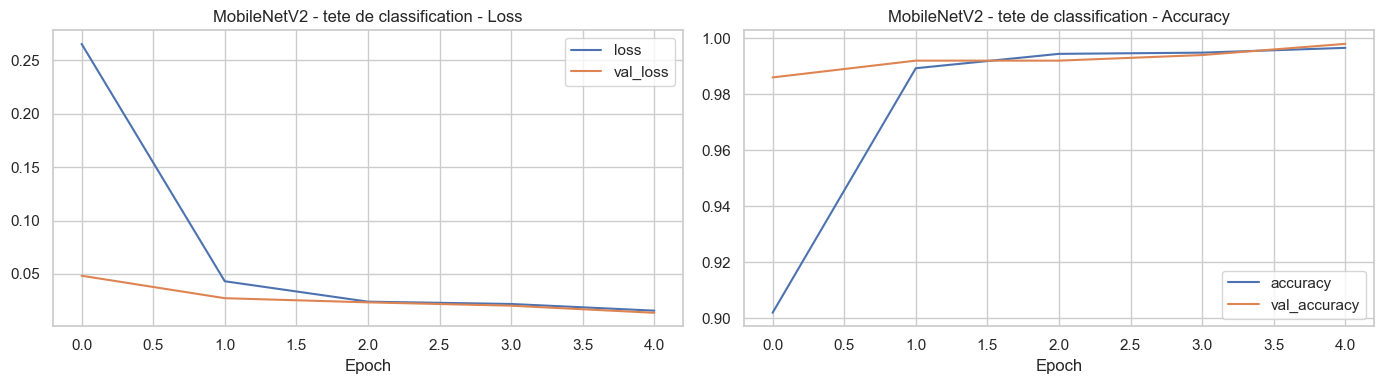

In [27]:
plot_history(history_head, "MobileNetV2 - tete de classification")


## 13. Fine-tuning

Le fine-tuning consiste a degeler une partie des couches du modele pre-entraine.
Cela permet d'adapter plus finement le modele au probleme des feuilles malades.


In [28]:
base_model.trainable = True

# On garde la plus grande partie du modele stable et on ajuste seulement les dernieres couches.
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [29]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


In [30]:
fine_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / "mobilenetv2_finetuned.keras"),
        save_best_only=True,
        monitor="val_loss",
    ),
]

train_gen.reset()
val_gen.reset()

history_fine = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_callbacks,
)


Epoch 1/5


 1/74 ━━━━━━━━━━━━━━━━━━━━ 8:31 7s/step - accuracy: 0.9688 - loss: 0.1085

 2/74 ━━━━━━━━━━━━━━━━━━━━ 18s 262ms/step - accuracy: 0.9609 - loss: 0.1375

 3/74 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9497 - loss: 0.1522

 4/74 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9408 - loss: 0.1640

...

71/74 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9954 - loss: 0.0374

72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9954 - loss: 0.0373

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9954 - loss: 0.0372

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9954 - loss: 0.0371

74/74 ━━━━━━━━━━━━━━━━━━━━ 25s 338ms/step - accuracy: 0.9949 - loss: 0.0297 - val_accuracy: 0.9920 - val_loss: 0.0185


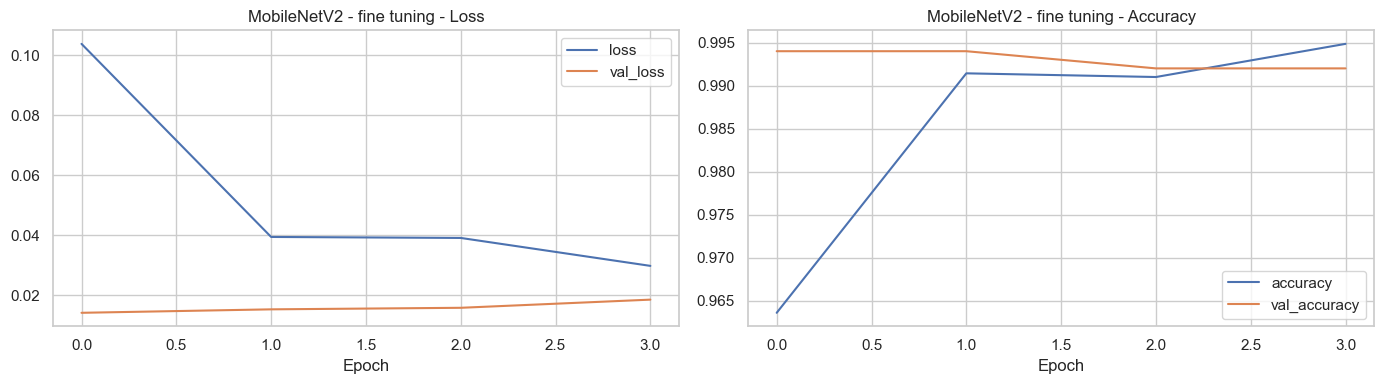

In [31]:
plot_history(history_fine, "MobileNetV2 - fine tuning")


## 14. Evaluation finale

A cette etape, on compare les deux approches avec des metriques claires.
Le F1-score est utile quand on veut tenir compte a la fois de la precision et du rappel.


In [32]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    predictions = model.predict(generator, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = generator.classes

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(true_labels, predicted_labels)

    summary = {
        "Modele": model_name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
    }

    return summary, report, cm


In [33]:
cnn_summary, cnn_report, cnn_cm = evaluate_model(cnn_model, test_gen, "CNN simple")
pd.DataFrame(cnn_report).T


,precision,recall,f1-score,support
common_rust,1.0,1.0,1.0,179.0
healthy,1.0,1.0,1.0,175.0
northern_leaf_blight,1.0,1.0,1.0,147.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,501.0
weighted avg,1.0,1.0,1.0,501.0


In [34]:
transfer_summary, transfer_report, transfer_cm = evaluate_model(
    transfer_model,
    test_gen,
    "MobileNetV2 finetune",
)

pd.DataFrame(transfer_report).T


,precision,recall,f1-score,support
common_rust,1.0,1.0,1.0,179.0
healthy,1.0,1.0,1.0,175.0
northern_leaf_blight,1.0,1.0,1.0,147.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,501.0
weighted avg,1.0,1.0,1.0,501.0


In [35]:
comparison_df = pd.DataFrame([cnn_summary, transfer_summary])
comparison_df = comparison_df.sort_values(by="F1-score", ascending=False)
comparison_df = comparison_df.round(4)
comparison_df


,Modele,Accuracy,Precision,Recall,F1-score
0,CNN simple,1.0,1.0,1.0,1.0
1,MobileNetV2 finetune,1.0,1.0,1.0,1.0


In [36]:
def plot_confusion(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(title)
    plt.xlabel("Prediction")
    plt.ylabel("Valeur reelle")
    plt.tight_layout()
    plt.show()


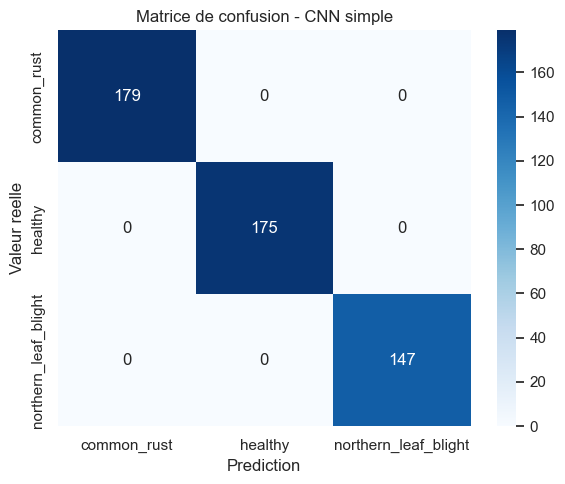

In [37]:
plot_confusion(cnn_cm, "Matrice de confusion - CNN simple")


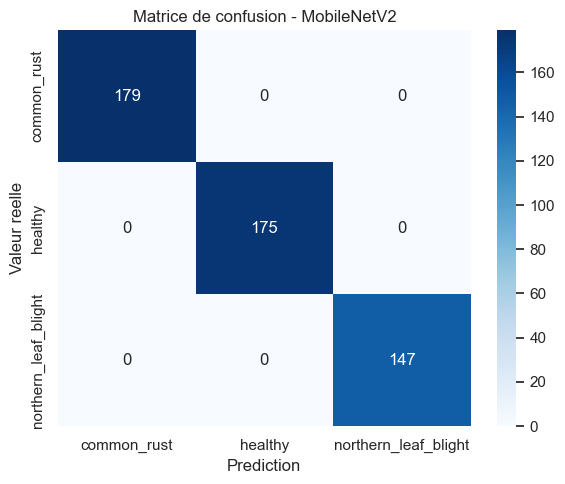

In [38]:
plot_confusion(transfer_cm, "Matrice de confusion - MobileNetV2")


## 15. Elements synchronises depuis les autres travaux

Ce notebook final reprend maintenant les apports utiles des autres contributions :

- travail d'Eli : audit des images, comparaison globale des approches, export TFLite et orientation mobile
- travail de Kevin : sauvegarde explicite du modele final au format Keras et rappel des pistes d'amelioration

L'objectif est de garder un seul notebook final, clair et exploitable pour la soutenance et pour l'application.

## 16. Comparaison directe des deux approches

Les graphiques suivants permettent de comparer rapidement le CNN simple et MobileNetV2 sur la validation.
Cela reprend l'idee de comparaison globale presente dans le notebook d'Eli.

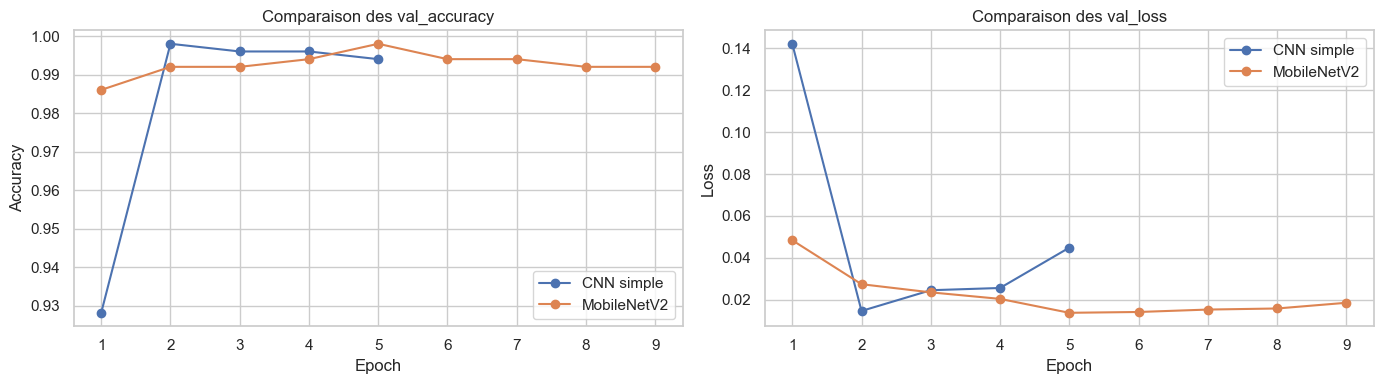

In [39]:
mobilenet_val_accuracy = list(history_head.history["val_accuracy"]) + list(history_fine.history["val_accuracy"])
mobilenet_val_loss = list(history_head.history["val_loss"]) + list(history_fine.history["val_loss"])

epochs_cnn = range(1, len(history_cnn.history["val_accuracy"]) + 1)
epochs_mobilenet = range(1, len(mobilenet_val_accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_cnn, history_cnn.history["val_accuracy"], marker="o", label="CNN simple")
axes[0].plot(epochs_mobilenet, mobilenet_val_accuracy, marker="o", label="MobileNetV2")
axes[0].set_title("Comparaison des val_accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs_cnn, history_cnn.history["val_loss"], marker="o", label="CNN simple")
axes[1].plot(epochs_mobilenet, mobilenet_val_loss, marker="o", label="MobileNetV2")
axes[1].set_title("Comparaison des val_loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
history_summary = pd.DataFrame(
    [
        {
            "Modele": "CNN simple",
            "Meilleure val_accuracy": max(history_cnn.history["val_accuracy"]),
            "Plus faible val_loss": min(history_cnn.history["val_loss"]),
        },
        {
            "Modele": "MobileNetV2",
            "Meilleure val_accuracy": max(mobilenet_val_accuracy),
            "Plus faible val_loss": min(mobilenet_val_loss),
        },
    ]
).round(4)

history_summary

,Modele,Meilleure val_accuracy,Plus faible val_loss
0,CNN simple,0.998,0.0146
1,MobileNetV2,0.998,0.0137


## 17. Choix du modele final

Le choix final ne depend pas uniquement du score. Si les performances sont proches, le modele le plus simple a deployer sur mobile est prefere.
Ici, MobileNetV2 est retenu comme modele final car il est leger et bien adapte a une conversion TFLite.

In [41]:
cnn_f1 = float(cnn_summary["F1-score"])
transfer_f1 = float(transfer_summary["F1-score"])

if transfer_f1 >= cnn_f1 - 0.01:
    final_model_name = "MobileNetV2 finetune"
    final_model = transfer_model
else:
    final_model_name = "CNN simple"
    final_model = cnn_model

FINAL_MODELS_DIR = PROJECT_DIR / "models" / "final"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_keras_path = FINAL_MODELS_DIR / "agrismart_model_final.keras"
final_model.save(final_keras_path)

print("Modele retenu :", final_model_name)
print("Fichier Keras final :", final_keras_path)
print("Ordre des classes :", class_names)

Modele retenu : MobileNetV2 finetune
Fichier Keras final : C:\projet phase 3\models\final\agrismart_model_final.keras
Ordre des classes : ['common_rust', 'healthy', 'northern_leaf_blight']


## 18. Exportation du modele final au format TFLite

Cette partie reprend l'idee du notebook d'Eli : produire un format leger pour l'application.
Le modele final retenu est donc exporte dans un dossier standard pour l'application.

In [42]:
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
tflite_model = converter.convert()

final_tflite_path = FINAL_MODELS_DIR / "agrismart_model_final.tflite"
final_tflite_path.write_bytes(tflite_model)

print("Fichier TFLite final :", final_tflite_path)
print("Taille du fichier (octets) :", final_tflite_path.stat().st_size)

INFO:tensorflow:Assets written to: C:\Users\DELLWO~1\AppData\Local\Temp\tmpkbzmkfzl\assets


INFO:tensorflow:Assets written to: C:\Users\DELLWO~1\AppData\Local\Temp\tmpkbzmkfzl\assets


Saved artifact at 'C:\Users\DELLWO~1\AppData\Local\Temp\tmpkbzmkfzl'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_170')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1585329737552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585326063440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517510480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585326063056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585326050384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517504720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517509520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517510096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517509712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1585517509136: TensorSpec(shape=(), dtype=tf.resource, name=None)


Fichier TFLite final : C:\projet phase 3\models\final\agrismart_model_final.tflite
Taille du fichier (octets) : 8901620


## 19. Metadonnees utiles pour l'application

L'application devra connaitre :
- le chemin du modele final
- la taille d'entree
- l'ordre exact des classes

On ecrit donc un petit fichier JSON de reference.

In [43]:
import json

model_metadata = {
    "model_name": final_tflite_path.name,
    "format": "tflite",
    "selected_model": final_model_name,
    "input_size": [160, 160, 3],
    "runtime_input_shape": [1, 160, 160, 3],
    "class_labels": class_names,
}

metadata_path = FINAL_MODELS_DIR / "model_metadata.json"
with metadata_path.open("w", encoding="utf-8") as f:
    json.dump(model_metadata, f, ensure_ascii=False, indent=2)

model_metadata

{'model_name': 'agrismart_model_final.tflite',
 'format': 'tflite',
 'selected_model': 'MobileNetV2 finetune',
 'input_size': [160, 160, 3],
 'runtime_input_shape': [1, 160, 160, 3],
 'class_labels': ['common_rust', 'healthy', 'northern_leaf_blight']}

In [44]:
interpreter = tf.lite.Interpreter(model_path=str(final_tflite_path))
input_index = interpreter.get_input_details()[0]["index"]
interpreter.resize_tensor_input(input_index, [1, 160, 160, 3])
interpreter.allocate_tensors()

print("Shape d'entree appliquee pour l'application :", interpreter.get_input_details()[0]["shape"])
print("Shape de sortie :", interpreter.get_output_details()[0]["shape"])

Shape d'entree appliquee pour l'application : [  1 160 160   3]
Shape de sortie : [1 3]


C:\Users\DELL WORKSTATION\anaconda3\envs\myfiance\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 20. Conclusion consolidee

Points a commenter dans la conclusion :
- le CNN simple sert de bonne baseline
- MobileNetV2 reste le meilleur choix si l'on vise une application mobile
- le modele final a ete archive au format `.keras`
- le modele final a aussi ete exporte au format `.tflite`
- l'ordre exact des classes est celui ecrit dans `model_metadata.json`
- les performances sur PlantVillage peuvent etre meilleures que sur des images reelles du terrain
